## Import and load Datasets 

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
%matplotlib inline

# Text Processing Libraries
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from collections import Counter
from nltk import ngrams

# Sentiment Analysis
from LeIA import SentimentIntensityAnalyzer

# Download required NLTK data
nltk.download('stopwords')
nltk.download('punkt')

# Machine Learning Libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
)
from sklearn.neighbors import KNeighborsClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report, 
    confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay, auc
)

[nltk_data] Downloading package stopwords to /home/pr/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/pr/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
dataset_paths = {'customers' : '../data/olist_customers_dataset.csv',
"geolocation" : "../data/olist_geolocation_dataset.csv",
"order_items" : "../data/olist_order_items_dataset.csv",
"order_payments" : '../data/olist_order_payments_dataset.csv',
"order_reviews" : '../data/olist_order_reviews_dataset.csv',
"orders" : '../data/olist_orders_dataset.csv',
"products" : '../data/olist_products_dataset.csv',
"sellers" : '../data/olist_sellers_dataset.csv',
"product_category" : '../data/product_category_name_translation.csv'}


In [4]:
# Load dataset

def load_dataset():

    data = {}
    for key in dataset_paths:
         data[key]= pd.read_csv(dataset_paths[key])

    return data

data = load_dataset()

In [5]:
df = data['orders'].merge(data['order_items'], on='order_id', how='inner')
df = df.merge(data['order_payments'], on='order_id', how='inner')
df = df.merge(data['order_reviews'], on='order_id', how='inner')
df = df.merge(data['products'], on='product_id', how='inner')
df = df.merge(data['customers'], on='customer_id', how='inner')
df = df.merge(data['sellers'], on='seller_id', how='inner')

In [6]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,31570,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,14840,guariba,SP


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 117329 entries, 0 to 117328
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117329 non-null  str    
 1   customer_id                    117329 non-null  str    
 2   order_status                   117329 non-null  str    
 3   order_purchase_timestamp       117329 non-null  str    
 4   order_approved_at              117314 non-null  str    
 5   order_delivered_carrier_date   116094 non-null  str    
 6   order_delivered_customer_date  114858 non-null  str    
 7   order_estimated_delivery_date  117329 non-null  str    
 8   order_item_id                  117329 non-null  int64  
 9   product_id                     117329 non-null  str    
 10  seller_id                      117329 non-null  str    
 11  shipping_limit_date            117329 non-null  str    
 12  price                          117329 non

In [8]:
df.isna().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                    15
order_delivered_carrier_date       1235
order_delivered_customer_date      2471
order_estimated_delivery_date         0
order_item_id                         0
product_id                            0
seller_id                             0
shipping_limit_date                   0
price                                 0
freight_value                         0
payment_sequential                    0
payment_type                          0
payment_installments                  0
payment_value                         0
review_id                             0
review_score                          0
review_comment_title             103437
review_comment_message            67650
review_creation_date                  0
review_answer_timestamp               0
product_category_name              1695


In [9]:
df['order_purchase_timestamp']

0         2017-10-02 10:56:33
1         2017-10-02 10:56:33
2         2017-10-02 10:56:33
3         2018-07-24 20:41:37
4         2018-08-08 08:38:49
                 ...         
117324    2018-02-06 12:58:58
117325    2017-08-27 14:46:43
117326    2018-01-08 21:28:27
117327    2018-01-08 21:28:27
117328    2018-03-08 20:57:30
Name: order_purchase_timestamp, Length: 117329, dtype: str

In [10]:
# Ensure timestamps are in datetime format
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

# Create useful features from order_purchase_timestamp
df['day_of_week_int'] = df['order_purchase_timestamp'].dt.weekday + 1  # Day of week as integer (1 = Monday, etc.)
df['hour'] = df['order_purchase_timestamp'].dt.hour                    # Hour of day
df['month'] = df['order_purchase_timestamp'].dt.month                  # Month as integer
df['year'] = df['order_purchase_timestamp'].dt.year                    # Year as integer
df['date'] = df['order_purchase_timestamp'].dt.to_period('M')          # Monthly period for time series analysis

# Calculate delivery time in days
df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_state,seller_zip_code_prefix,seller_city,seller_state,day_of_week_int,hour,month,year,date,delivery_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,SP,9350,maua,SP,1,10,10,2017,2017-10,8.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,SP,9350,maua,SP,1,10,10,2017,2017-10,8.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,SP,9350,maua,SP,1,10,10,2017,2017-10,8.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,BA,31570,belo horizonte,SP,2,20,7,2018,2018-07,13.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,GO,14840,guariba,SP,3,8,8,2018,2018-08,9.0


In [11]:
# Renaming the column to correct the spelling
df.rename(columns={'product_name_lenght': 'product_name_length'}, inplace=True)

## Exploratory Data Analysis

In [12]:
import seaborn as sns
# Set color palette for Seaborn
colors = ["#26536f", "#3b96b7", "#749ca8", "#b6a98d", "#c78a4d", "#854927"]
sns.set_palette(colors)

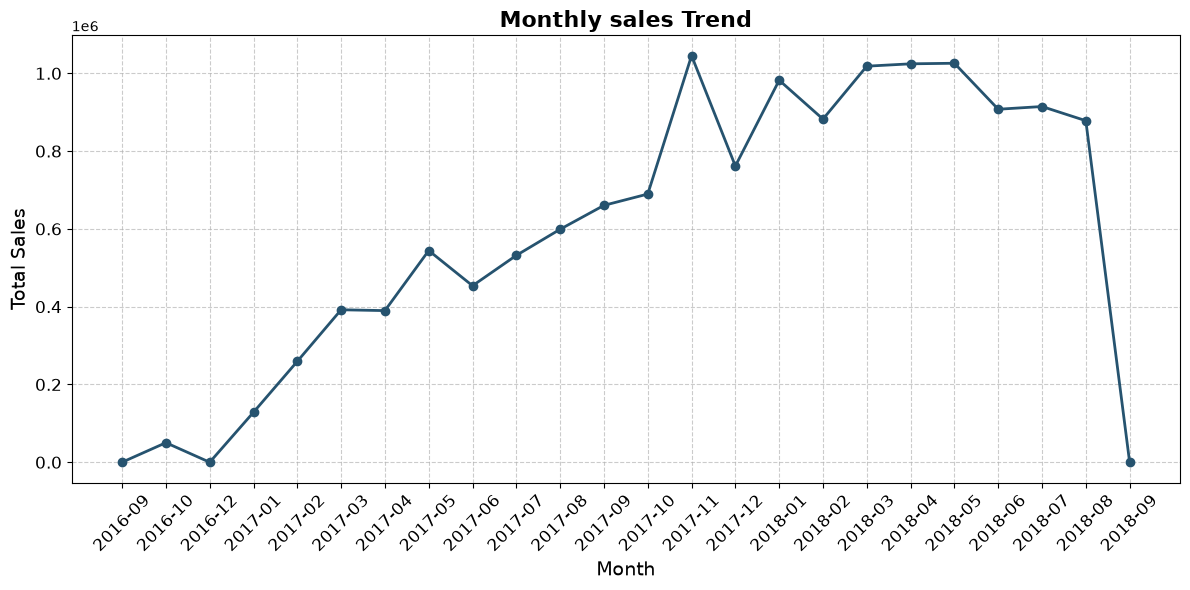

In [13]:
#monthly sales trend
monthly_sales = df.groupby(df['order_purchase_timestamp'].dt.to_period('M')).agg({'price':'sum'})

# set figure size 
plt.figure(figsize=(12,6))

# make plot
plt.plot(monthly_sales.index.astype(str), monthly_sales['price'], marker='o' ,linestyle='-' , color=colors[0], linewidth=2)

#titles, labels, ticks
plt.title('Monthly sales Trend', fontsize=16 , fontweight='bold')
plt.xlabel('Month',fontsize=14)
plt.ylabel('Total Sales', fontsize=14)

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.grid(visible=True, linestyle='--', alpha=0.65)

plt.tight_layout()
plt.show()

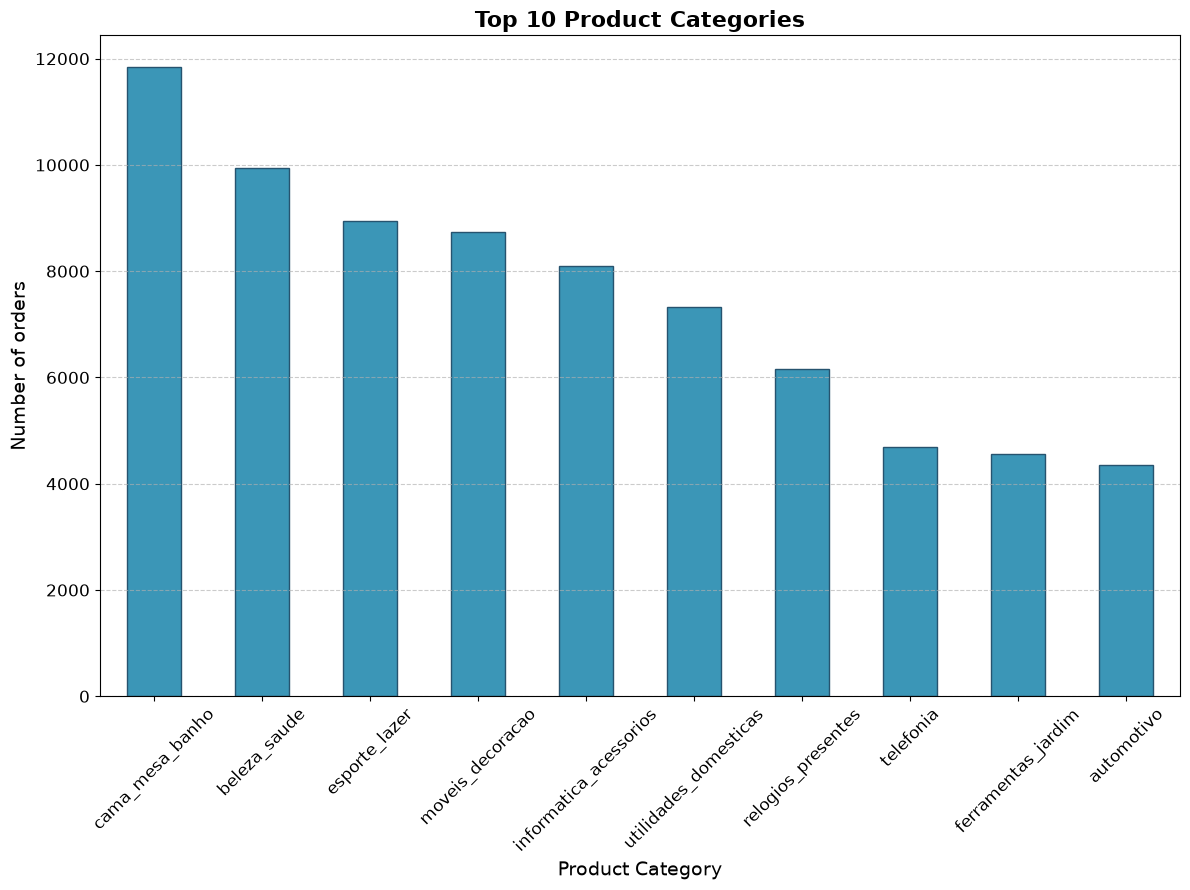

In [14]:
#sales by category

#plot
plt.figure(figsize=(12,9))

top_categories = df['product_category_name'].value_counts().head(10)
top_categories.plot(kind='bar', color=colors[1], edgecolor=colors[0])

#title labels ticks
plt.title('Top 10 Product Categories', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=14)
plt.ylabel('Number of orders', fontsize=14)

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.65)

plt.tight_layout()
plt.show()

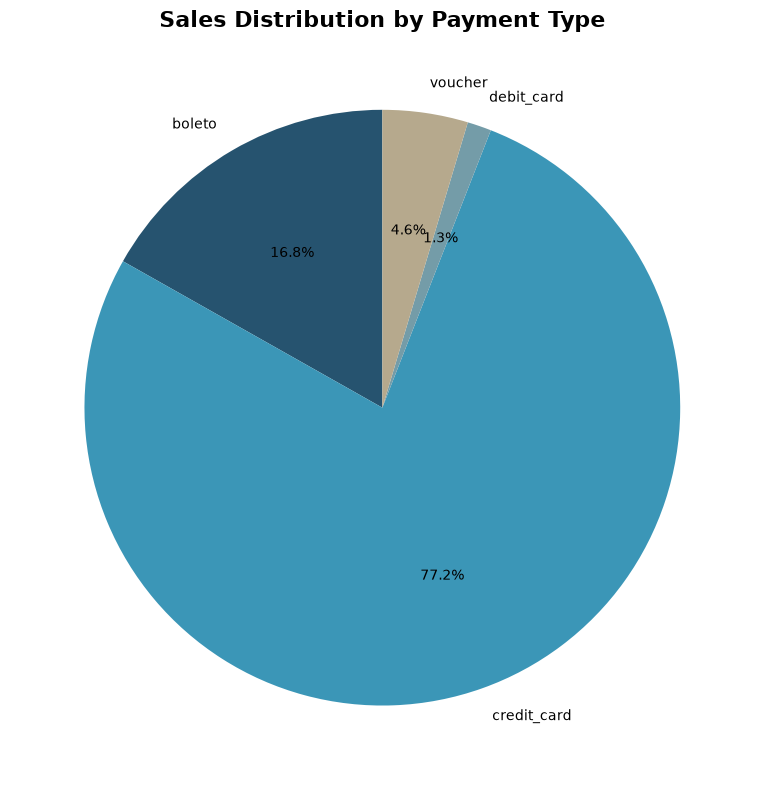

In [15]:
# proportion of total sales by payment type

#plot
plt.figure(figsize=(8,8))

sales_by_payment = df.groupby('payment_type')['price'].sum()
sales_by_payment.plot(kind='pie', autopct='%1.1f%%',startangle=90, colors=colors)

#title
plt.title('Sales Distribution by Payment Type', fontsize=16, fontweight='bold')

plt.ylabel('')

plt.tight_layout()
plt.show()

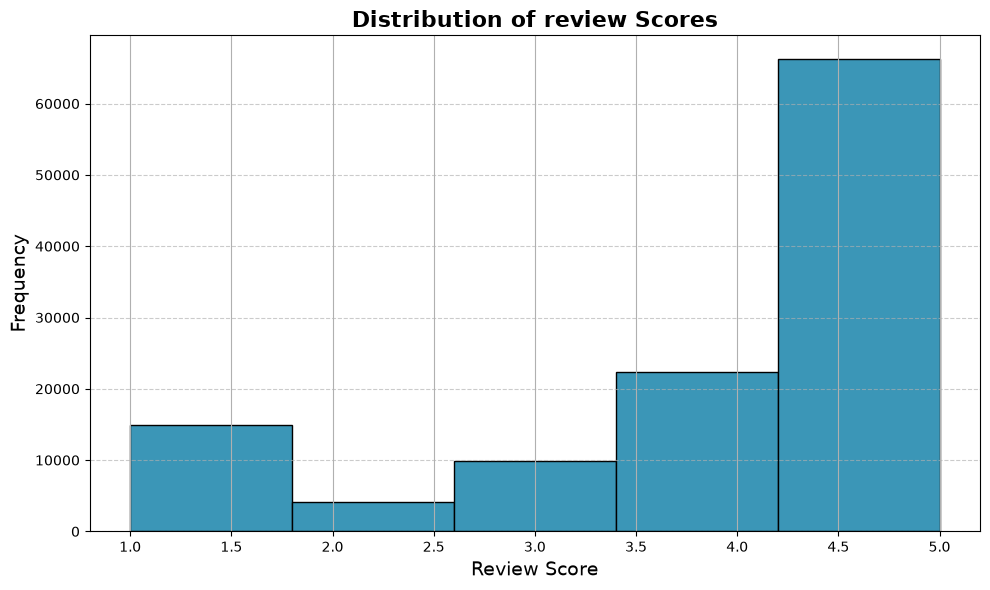

In [16]:
#distribution of review score

plt.figure(figsize=(10,6))

df['review_score'].hist(bins=5, color=colors[1], edgecolor='black')

#title
plt.title('Distribution of review Scores', fontsize=16, fontweight='bold')
plt.xlabel('Review Score', fontsize=14)
plt.ylabel('Frequency',fontsize=14)

plt.grid(axis='y',linestyle='--', alpha=0.65)

plt.tight_layout()
plt.show()

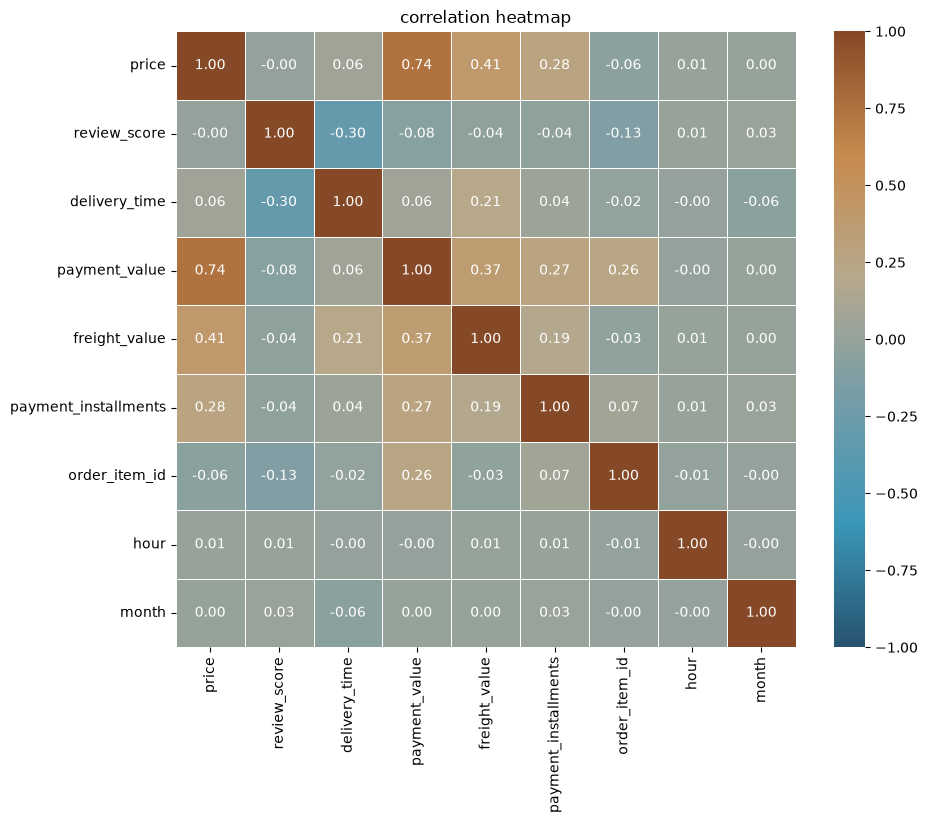

In [17]:
#corelation

correlation_features= df[['price', 'review_score', 'delivery_time','payment_value', 'freight_value', 'payment_installments', 'order_item_id','hour','month']]

#correlation matrix
correlation = correlation_features.corr()

#colormap
custom_colors = colors
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', custom_colors)

plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap=custom_cmap, vmin=-1, vmax=1, fmt='.2f', linewidths=.5)
plt.title('correlation heatmap')
plt.show()

In [18]:
# delivery time by product category
category_counts = df['product_category_name'].value_counts()

#threshold to decide which categories to keep
threshold = 3000
common_categories = category_counts[category_counts >= threshold].index

# Create a new column for simplified categories
df['simplified_category'] = df['product_category_name'].where(df['product_category_name'].isin(common_categories),'other')

/tmp/ipykernel_10362/2510109880.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='delivery_time', y='simplified_category', data=df, palette=colors)
/tmp/ipykernel_10362/2510109880.py:4: UserWarning: 
The palette list has fewer values (6) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(x='delivery_time', y='simplified_category', data=df, palette=colors)


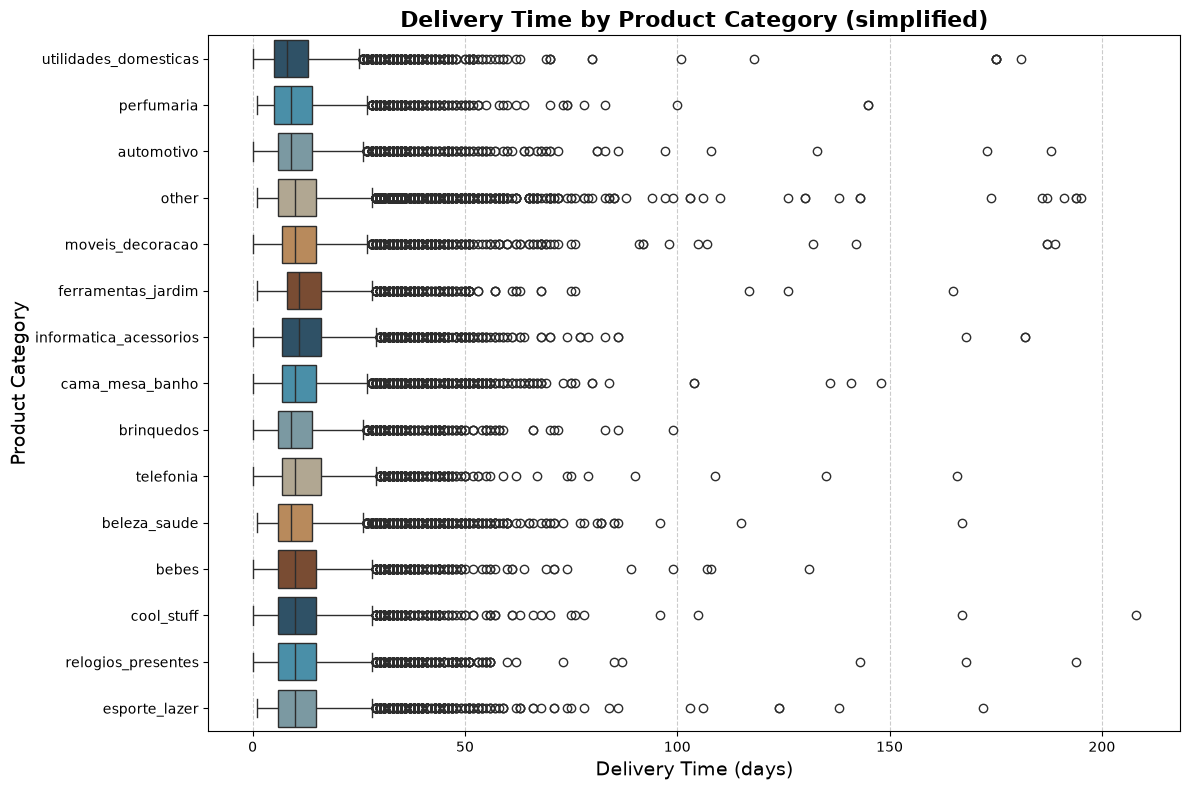

In [19]:
#box plot
plt.figure(figsize=(12,8))

sns.boxplot(x='delivery_time', y='simplified_category', data=df, palette=colors)

# Overlay swarm plot to show individual points
# sns.swarmplot(x='delivery_time', y='simplified_category', data=df, color='k', alpha=0.6, size=3)

#titles
plt.title('Delivery Time by Product Category (simplified)', fontsize=16, fontweight ='bold')
plt.xlabel('Delivery Time (days)', fontsize=14)
plt.ylabel('Product Category', fontsize=14)

plt.grid(axis='x', linestyle='--', alpha=0.65)

plt.tight_layout()
plt.show()

/tmp/ipykernel_10362/4196800027.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='day_of_week_int', y='delivery_time', palette=colors)
/tmp/ipykernel_10362/4196800027.py:4: UserWarning: 
The palette list has fewer values (6) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(data=df, x='day_of_week_int', y='delivery_time', palette=colors)


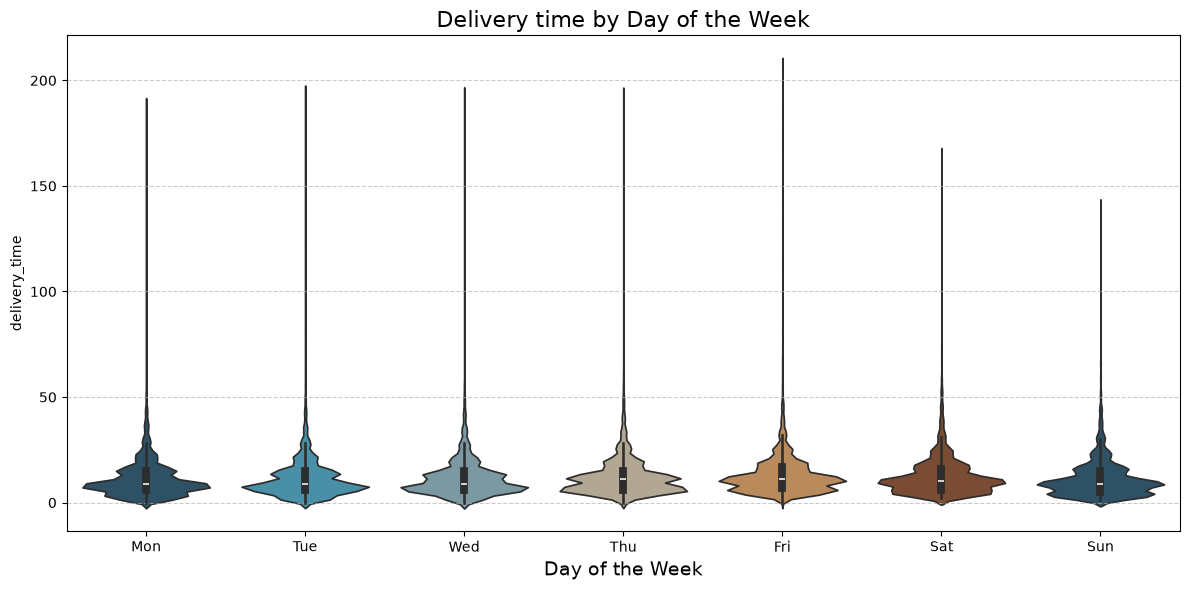

In [20]:
#delivery time by day of the week

plt.figure(figsize=(12,6))
sns.violinplot(data=df, x='day_of_week_int', y='delivery_time', palette=colors)

#title
plt.title('Delivery time by Day of the Week', fontsize=16)
plt.xlabel('Day of the Week', fontsize=14)
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu','Fri','Sat','Sun'])
plt.grid(axis='y', linestyle='--', alpha=0.65)

plt.tight_layout()
plt.show()

/tmp/ipykernel_10362/1375058547.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month_year', y='delivery_time', data=monthly_delivery_time, palette=colors)
/tmp/ipykernel_10362/1375058547.py:8: UserWarning: 
The palette list has fewer values (6) than needed (24) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x='month_year', y='delivery_time', data=monthly_delivery_time, palette=colors)


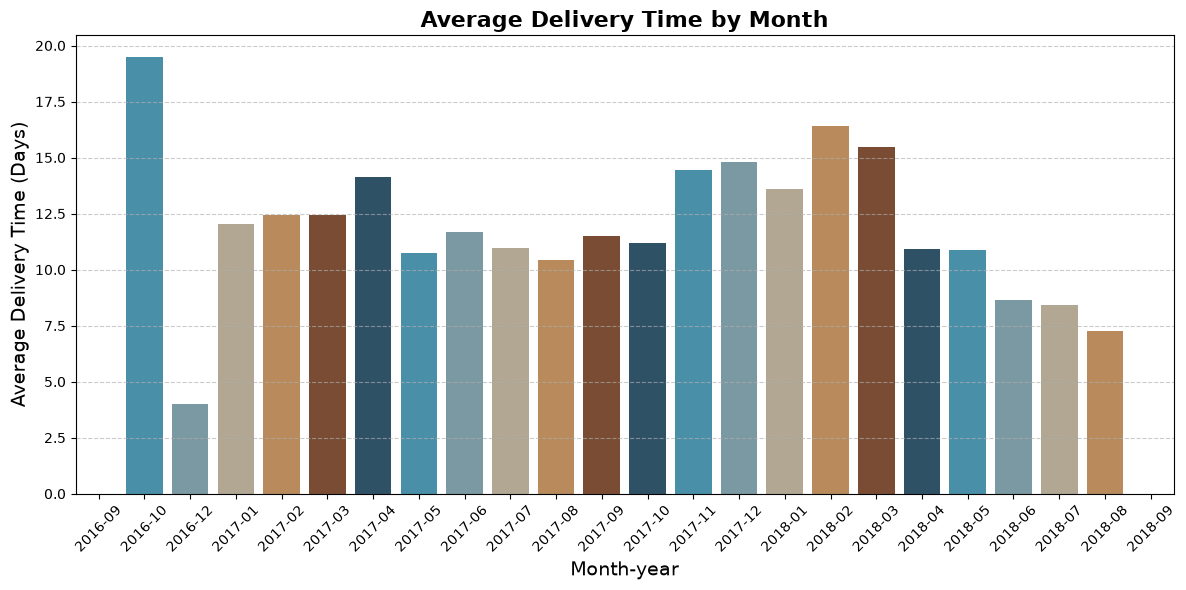

In [21]:
#average delivery time by month

df['month_year'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_delivery_time = df.groupby('month_year')['delivery_time'].mean().reset_index()

#plot
plt.figure(figsize=(12,6))
sns.barplot(x='month_year', y='delivery_time', data=monthly_delivery_time, palette=colors)

#title
plt.title('Average Delivery Time by Month', fontsize=16, fontweight='bold')
plt.xlabel('Month-year', fontsize=14)
plt.ylabel('Average Delivery Time (Days)', fontsize=14)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.65)
plt.tight_layout()
plt.show()

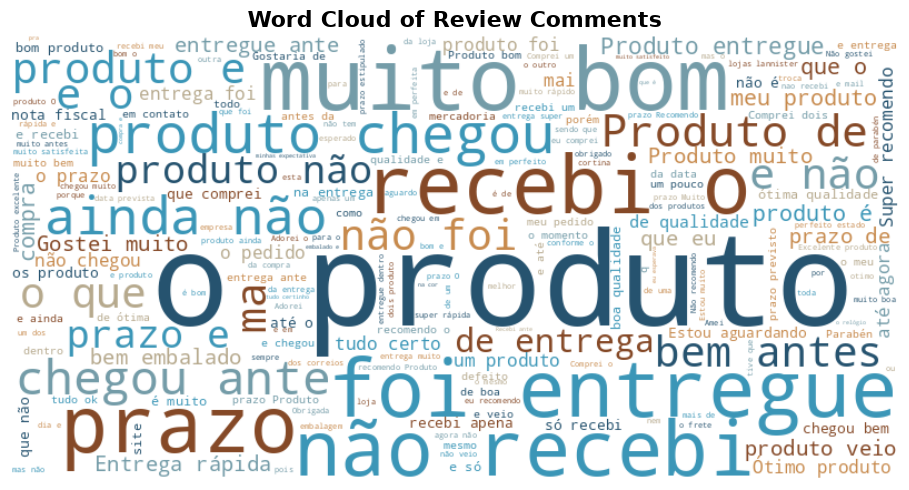

In [22]:
# Define a color function
def color_func(word, font_size, position, orientation, random_state=42, **kwargs):
    return np.random.choice(colors)

# Example: Word cloud from review comments
plt.figure(figsize=(10, 5))

wordcloud = WordCloud(width=800, height=400, background_color='white', color_func=color_func).generate(' '.join(df['review_comment_message'].dropna()))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Hide axesWordCloud(width=800, height=400, background_color='white', color_func=color_func).generate(' '.join(df['review_comment_message'].dropna()))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Hide axes
plt.title('Word Cloud of Review Comments', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

## Nlp

In [23]:
nlp_df = df[['review_comment_title', 'review_comment_message', 'product_category_name']]

In [24]:
nlp_df.head()

,review_comment_title,review_comment_message,product_category_name
0,NaN,"Não testei o produto ainda, mas ele veio corre...",utilidades_domesticas
1,NaN,"Não testei o produto ainda, mas ele veio corre...",utilidades_domesticas
2,NaN,"Não testei o produto ainda, mas ele veio corre...",utilidades_domesticas
3,Muito boa a loja,Muito bom o produto.,perfumaria
4,NaN,NaN,automotivo


In [25]:
nlp_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 117329 entries, 0 to 117328
Data columns (total 3 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   review_comment_title    13892 non-null   str  
 1   review_comment_message  49679 non-null   str  
 2   product_category_name   115634 non-null  str  
dtypes: str(3)
memory usage: 2.7 MB


In [26]:
nlp_df.product_category_name.nunique()

73

## data cleaning

In [27]:
nan_counts = nlp_df.isna().sum()
nan_counts

review_comment_title      103437
review_comment_message     67650
product_category_name       1695
dtype: int64

In [28]:
nan_count_review_comment_message = nlp_df['review_comment_message'].isna().sum()
nan_count_review_comment_message

np.int64(67650)

In [29]:
def remove_duplicates_nlp_df(nlp_df, column_name='review_comment_message'):

    nlp_df = nlp_df.drop_duplicates(subset=[column_name], keep='first').reset_index(drop=True)

    print(f"total entries after removing duplicates in '{column_name}':'{nlp_df.shape[0]}")

    return nlp_df

nlp_df = remove_duplicates_nlp_df(nlp_df, 'review_comment_message')

nlp_df.head()

total entries after removing duplicates in 'review_comment_message':'35692


,review_comment_title,review_comment_message,product_category_name
0,NaN,"Não testei o produto ainda, mas ele veio corre...",utilidades_domesticas
1,Muito boa a loja,Muito bom o produto.,perfumaria
2,NaN,NaN,automotivo
3,NaN,O produto foi exatamente o que eu esperava e e...,pet_shop
4,NaN,fiquei triste por n ter me atendido.,NaN


In [30]:
def clean_reviews(df):

    df = df.dropna(subset=['review_comment_message', 'review_comment_title', 'product_category_name']).reset_index(drop=True)

    df = df.drop_duplicates(subset=['review_comment_message'])

    return df

df_cleaned = clean_reviews(nlp_df)

df_cleaned.head()

,review_comment_title,review_comment_message,product_category_name
0,Muito boa a loja,Muito bom o produto.,perfumaria
1,Nota dez,Obrigado pela atenção. Lojas lannister perfeit...,perfumaria
2,Ótimo,Sempre vou comprar aqui pois é a melhor parabéns,papelaria
3,NÃO RECOMENDO!!!!,Até o momento não recebi o produto Protetor De...,bebes
4,Enganadores,Foi entregue um produto divergente do que eu h...,climatizacao


In [31]:
df_cleaned.isna().sum()

review_comment_title      0
review_comment_message    0
product_category_name     0
dtype: int64

## Text Preprocessing

In [32]:
# define portuguese stopwords
STOP_WORDS = set (stopwords.words('portuguese'))

# Helper function to clean and tokenize text
def clean_and_tokenize(text):
    # Ensure the text is a string
    if not isinstance(text, str):
        return "", []
    
    # Convert to lowercase, remove punctuation, and split into words
    cleaned_text = text.lower().translate(str.maketrans('', '', string.punctuation))
    words = cleaned_text.split()
    
    # Remove stopwords and create tokens
    filtered_words = [word for word in words if word not in STOP_WORDS]
    return " ".join(filtered_words), filtered_words

# Main function to preprocess and clean the dataframe
def preprocess_nlp_df(df):
    # Clean, remove stopwords, and tokenize comments
    df[['review_comment_message_clean', 'review_comment_message_tokens']] = df['review_comment_message'].apply(
        lambda text: pd.Series(clean_and_tokenize(text))
    )
    
    # Remove rows with NaN values in key columns
    df.dropna(subset=['review_comment_title', 'review_comment_message'], inplace=True)
    
    # Drop duplicate rows based on the 'review_comment_message' and 'review_comment_title' columns
    df.drop_duplicates(subset=['review_comment_message', 'review_comment_title'], inplace=True)
    
    return df.reset_index(drop=True)

# Preprocess the dataset 
nlp_df = preprocess_nlp_df(nlp_df)

# Display the first records to check
nlp_df[['review_comment_message', 'review_comment_message_clean', 'review_comment_message_tokens']].head()


,review_comment_message,review_comment_message_clean,review_comment_message_tokens
0,Muito bom o produto.,bom produto,"[bom, produto]"
1,Obrigado pela atenção. Lojas lannister perfeit...,obrigado atenção lojas lannister perfeito tudo,"[obrigado, atenção, lojas, lannister, perfeito..."
2,Sempre vou comprar aqui pois é a melhor parabéns,sempre vou comprar aqui pois melhor parabéns,"[sempre, vou, comprar, aqui, pois, melhor, par..."
3,Até o momento não recebi o produto Protetor De...,momento recebi produto protetor colchão berço ...,"[momento, recebi, produto, protetor, colchão, ..."
4,Foi entregue um produto divergente do que eu h...,entregue produto divergente havia comprado alé...,"[entregue, produto, divergente, havia, comprad..."


In [33]:
# Initialize the Sentiment Analyzer once
analyzer = SentimentIntensityAnalyzer()

def classify_sentiment(df, column_name='review_comment_message_clean'):
    # Vectorized function to get sentiment classification
    def get_sentiment_classification(text):
        scores = analyzer.polarity_scores(text)
        if scores['compound'] >= 0.05:
            return 'Positive'
        elif scores['compound'] <= -0.05:
            return 'Negative'
        else:
            return 'Neutral'
    
    # Apply sentiment analysis using map for faster iteration
    df[f'{column_name}_sentiment'] = df[column_name].map(get_sentiment_classification)
    return df

# Classify sentiment in 'nlp_df' based on the 'review_comment_message_clean' column
nlp_df = classify_sentiment(nlp_df, 'review_comment_message_clean')

# Display the sentiment results
nlp_df[['review_comment_message_clean', 'review_comment_message_clean_sentiment']].head(25)

,review_comment_message_clean,review_comment_message_clean_sentiment
0,bom produto,Positive
1,obrigado atenção lojas lannister perfeito tudo,Positive
2,sempre vou comprar aqui pois melhor parabéns,Positive
3,momento recebi produto protetor colchão berço ...,Negative
4,entregue produto divergente havia comprado alé...,Neutral
5,produto veio bem lacrado todo original,Positive
6,prazo entrega excelente produto cuidadosamente...,Positive
7,recebi apenas 1 unidade solicitada deveriam 2 ...,Negative
8,entrega antes data marcada excelente,Positive
9,somente mala pequena bordo avião 360º viagem s...,Neutral


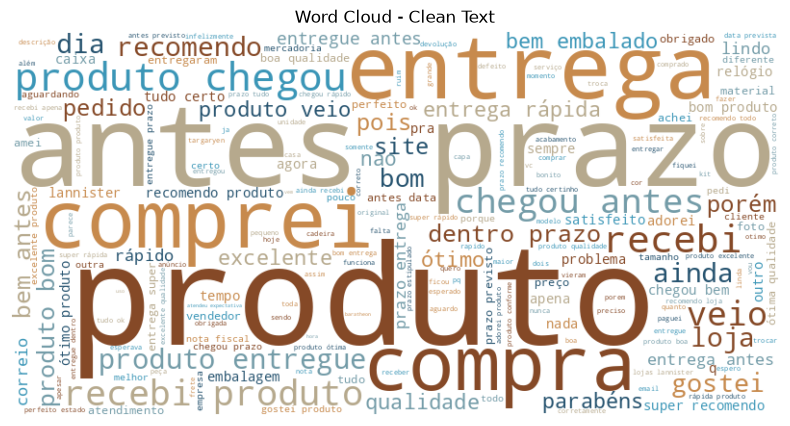

In [34]:
# Concatenate all non-null texts from the 'cleaned_text' column into a single string
text_combined = " ".join(nlp_df['review_comment_message_clean'].dropna())

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', color_func=color_func).generate(text_combined)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("Word Cloud - Clean Text")
plt.axis("off")  # Remove the axes
plt.show()

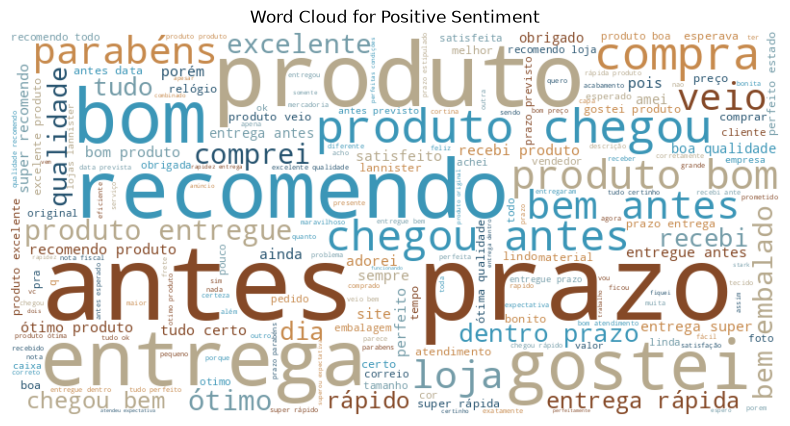

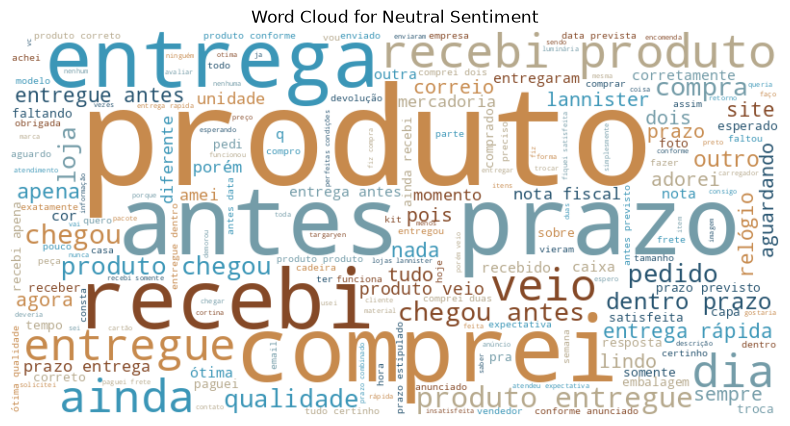

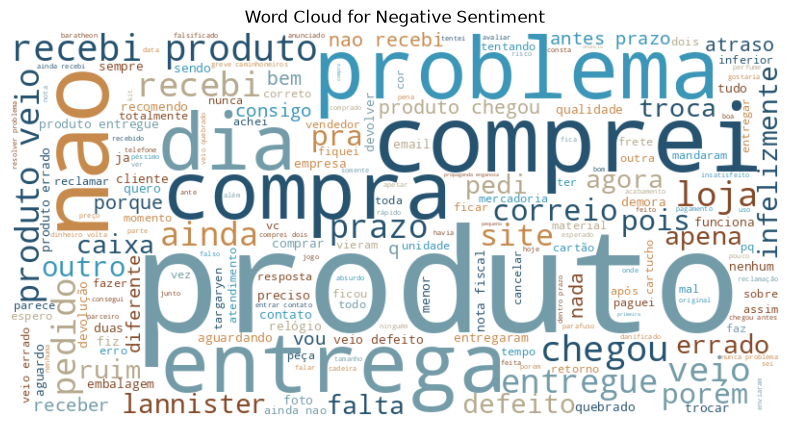

In [35]:
def plot_word_clouds_by_sentiment(df, text_column='review_comment_message_clean', sentiment_column='review_comment_message_clean_sentiment'):
    # Filter text by sentiment
    sentiments = ['Positive', 'Neutral', 'Negative']
    
    for sentiment in sentiments:
        # Filter data by current sentiment
        text_data = " ".join(df[df[sentiment_column] == sentiment][text_column].dropna())
        
        # Generate the word cloud
        wordcloud = WordCloud(width=800, height=400, background_color='white', color_func=color_func).generate(text_data)
        
        # Plot the word cloud
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Word Cloud for {sentiment} Sentiment')
        plt.show()
        
# Generate word clouds based on sentiment for the specified columns
plot_word_clouds_by_sentiment(nlp_df, 'review_comment_message_clean', 'review_comment_message_clean_sentiment')

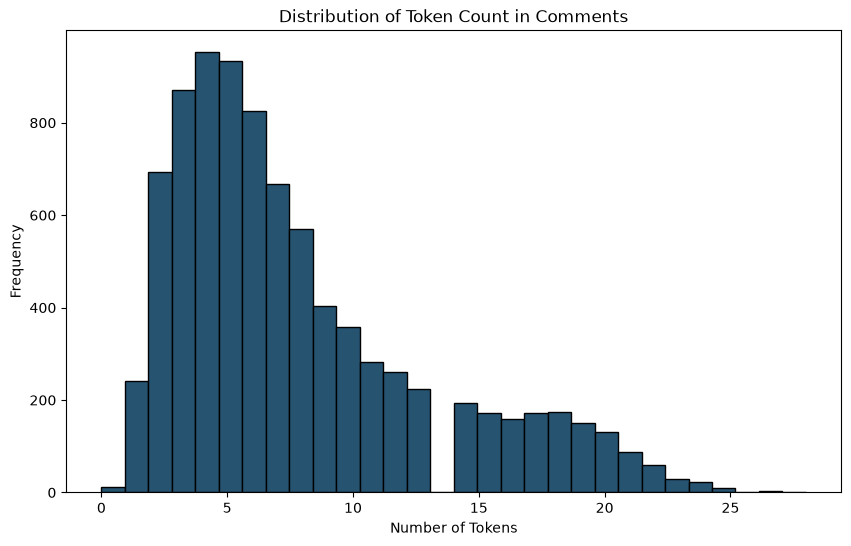

In [36]:
def plot_token_count_distribution(df, token_column='review_comment_message_tokens'):
    # Calculate the number of tokens for each entry
    df['token_count'] = df[token_column].apply(len)
    
    # Plot the distribution of token counts
    plt.figure(figsize=(10, 6))
    plt.hist(df['token_count'], bins=30, edgecolor='black')
    plt.xlabel('Number of Tokens')
    plt.ylabel('Frequency')
    plt.title('Distribution of Token Count in Comments')
    plt.show()
    
# Generate the token count distribution plot
plot_token_count_distribution(nlp_df, 'review_comment_message_tokens')

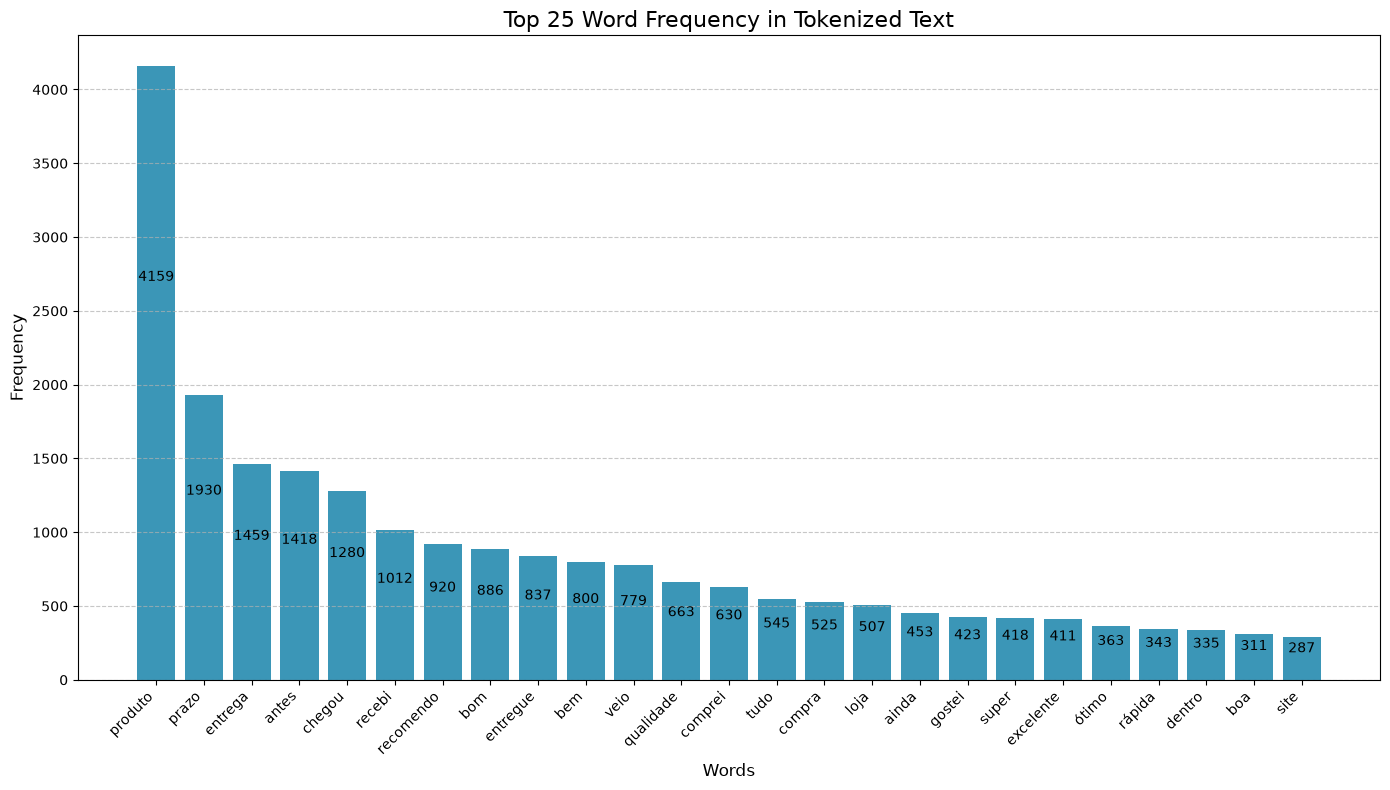

In [37]:
# Function to get top N tokens or n-grams
def get_top_tokens(df, token_column='review_comment_message_tokens', top_n=50):
    all_tokens = [token for tokens in df[token_column] for token in tokens]
    token_counts = Counter(all_tokens)
    return token_counts.most_common(top_n)

# Function to create a DataFrame from frequency counts
def create_frequency_df(counter, columns=['Word', 'Frequency']):
    return pd.DataFrame(counter.items(), columns=columns)

# General plotting function for bar charts
def plot_top_frequencies(df, title, xlabel, column_name):
    plt.figure(figsize=(14, 8))
    bars = plt.bar(df[column_name], df['Frequency'], color=colors[1])
    
    # Add labels
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width() / 2., bar.get_height() - max(5, bar.get_height() * 0.35), 
                 f'{int(bar.get_height())}', ha='center', color='black', fontsize=10)

    # Customize and show plot
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title(title, fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Get top tokens and plot
top_50_tokens = get_top_tokens(nlp_df, 'review_comment_message_tokens', 50)
top_50_tokens_df = create_frequency_df(dict(top_50_tokens))
plot_top_frequencies(top_50_tokens_df.head(25), 'Top 25 Word Frequency in Tokenized Text', 'Words', 'Word')

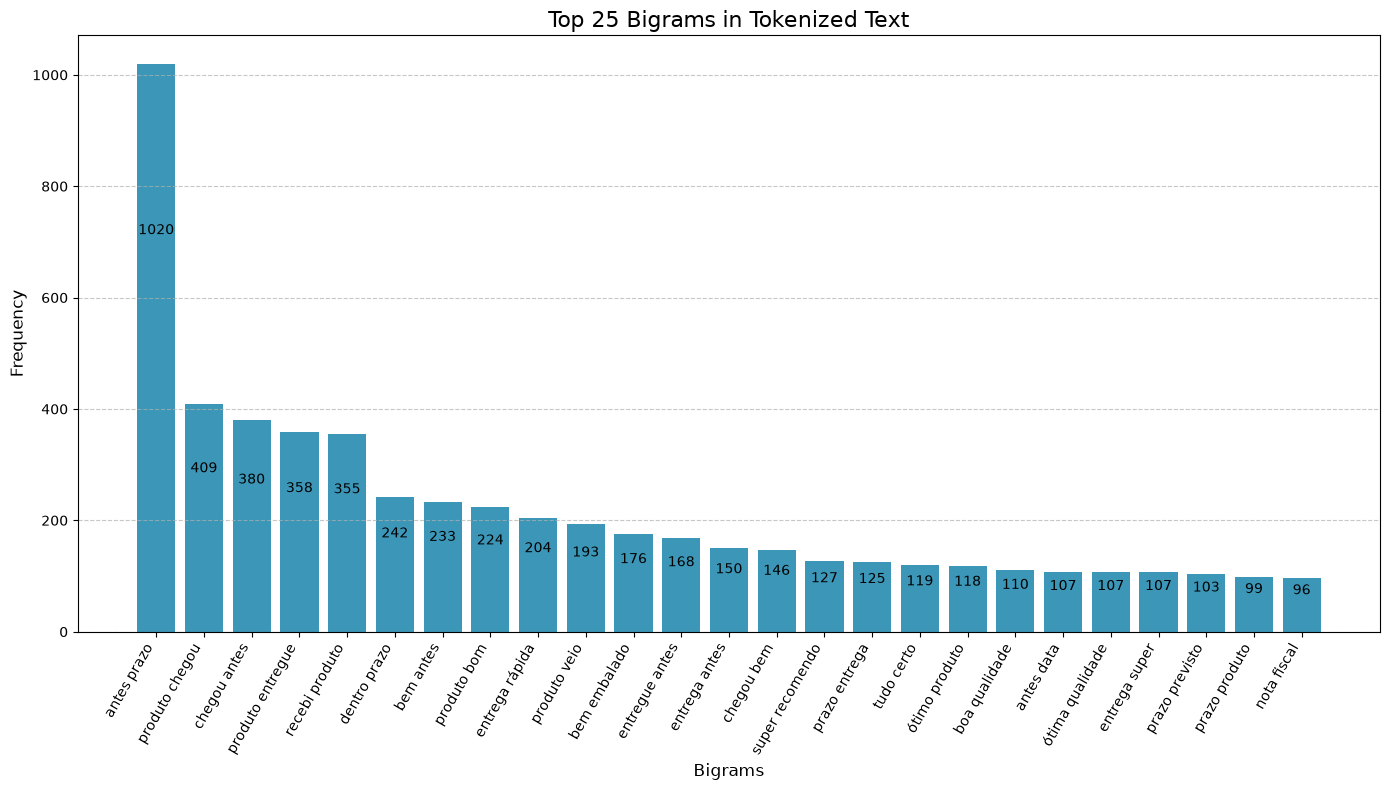

In [38]:
# N-gram generator and frequency counter
def get_top_ngrams(tokens_list, n=2, top_n=25):
    ngram_counts = Counter(
        ngram for tokens in tokens_list if tokens for ngram in ngrams(tokens, n)
    )
    # Create DataFrame directly from the most common n-grams
    return pd.DataFrame(ngram_counts.most_common(top_n), columns=['Bigram', 'Frequency'])

# Generate top 25 bigrams and plot
top_bigrams_df = get_top_ngrams(nlp_df['review_comment_message_tokens'], n=2, top_n=25)

# Plotting
plt.figure(figsize=(14, 8))
bars = plt.bar(
    [f'{gram[0]} {gram[1]}' for gram in top_bigrams_df['Bigram']], 
    top_bigrams_df['Frequency'], color=colors[1])

# Add count labels on top of the bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2., bar.get_height() - max(5, bar.get_height() * 0.3), 
             f'{int(bar.get_height())}', ha='center', color='black', fontsize=10)

# Customize the chart
plt.xlabel('Bigrams', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 25 Bigrams in Tokenized Text', fontsize=16)
plt.xticks(rotation=60, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


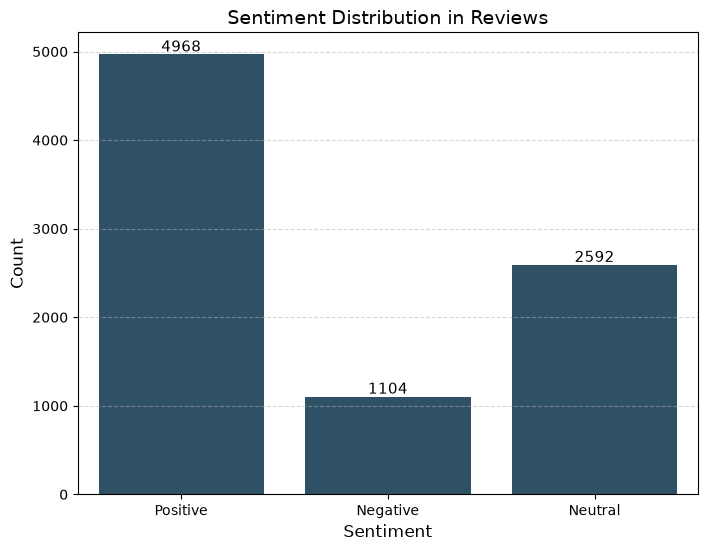

In [39]:
# Plot the sentiment count
plt.figure(figsize=(8, 6))
ax = sns.countplot(x="review_comment_message_clean_sentiment", data=nlp_df)

# Add labels and title
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Sentiment Distribution in Reviews", fontsize=14)

# Display value labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')

# Reduce gridline visibility for a cleaner look
plt.grid(visible=True, axis='y', linestyle='--', alpha=0.5)

plt.show()

## preprocessing

In [40]:
X = nlp_df['review_comment_message'] # Text column
y = nlp_df['review_comment_message_clean_sentiment'] # Target column

In [43]:
# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
# Convert categorical classes
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)  
y_test_encoded = label_encoder.transform(y_test)

# Check if the conversion was successful
print(f"Unique values ​​in y_train_encoded after encoding: {y_train_encoded}")

# Viewing
label_encoder

Unique values ​​in y_train_encoded after encoding: [1 2 2 ... 2 1 2]


Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Holds the label for each class.","ndarray[object](3,)","['Negative','Neutral','Positive']"


In [45]:
# Vectorize text using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000) # Optional limit for the number of features

# Transform texts into TF-IDF vectors
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Convert to dense arrays (if necessary for some models)
X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

# Viewing
vectorizer

,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",5000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'


## Ml

In [46]:
%%time 

# Initialize models
models = {
    "GaussianNB": GaussianNB(),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=100, random_state=42),
    "LogisticRegression": LogisticRegression(random_state=50, max_iter=1000),
    "AdaBoostClassifier": AdaBoostClassifier(random_state=45),
    "KNeighborsClassifier": KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42),
    "SVC": SVC(kernel='linear', random_state=42, probability=True),
}

# Train models and calculate accuracy scores
results = []
for name, model in models.items():
    model.fit(X_train_dense, y_train_encoded)
    train_accuracy = accuracy_score(y_train_encoded, model.predict(X_train_dense))
    test_accuracy = accuracy_score(y_test_encoded, model.predict(X_test_dense))
    results.append({"Model": name, "Training Accuracy": train_accuracy, "Testing Accuracy": test_accuracy})
    
pd.DataFrame(results)

/home/pr/Documents/prj/mlops-prj/customer-satisfaction-analysis/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


CPU times: user 21min 17s, sys: 6.18 s, total: 21min 24s
Wall time: 19min 26s


,Model,Training Accuracy,Testing Accuracy
0,GaussianNB,0.556774,0.353145
1,DecisionTreeClassifier,0.999856,0.815926
2,RandomForestClassifier,0.999856,0.832083
3,LogisticRegression,0.935940,0.871321
4,AdaBoostClassifier,0.623431,0.613964
5,KNeighborsClassifier,0.555331,0.518754
6,GradientBoostingClassifier,0.883422,0.852279
7,SVC,0.960179,0.890364


/tmp/ipykernel_10362/602648851.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=imp_df, palette=colors)
/tmp/ipykernel_10362/602648851.py:10: UserWarning: 
The palette list has fewer values (6) than needed (20) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x="Importance", y="Feature", data=imp_df, palette=colors)


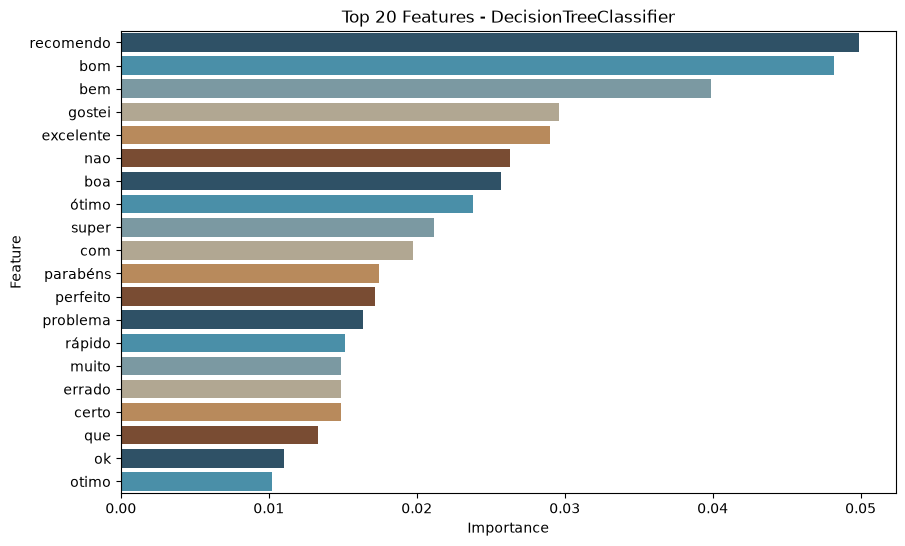

/tmp/ipykernel_10362/602648851.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=imp_df, palette=colors)
/tmp/ipykernel_10362/602648851.py:10: UserWarning: 
The palette list has fewer values (6) than needed (20) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x="Importance", y="Feature", data=imp_df, palette=colors)


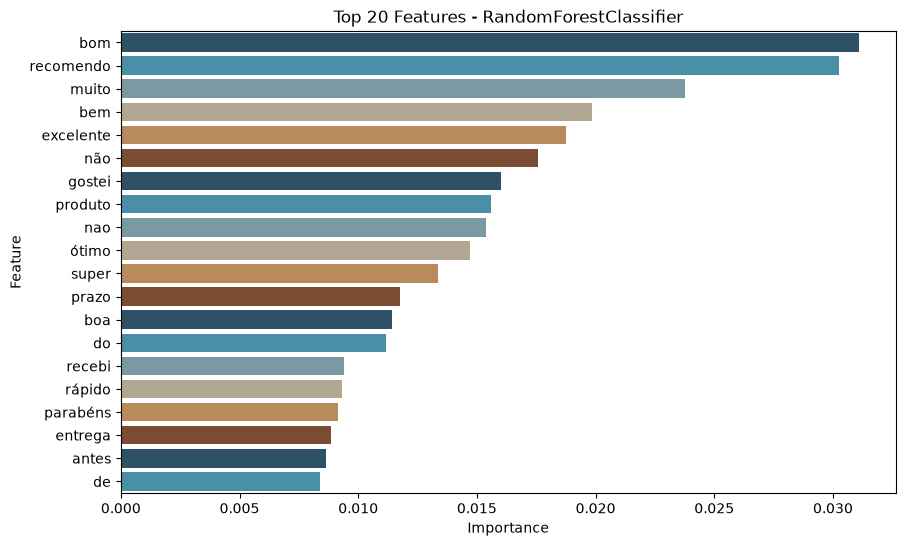

/tmp/ipykernel_10362/602648851.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=imp_df, palette=colors)
/tmp/ipykernel_10362/602648851.py:10: UserWarning: 
The palette list has fewer values (6) than needed (20) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x="Importance", y="Feature", data=imp_df, palette=colors)


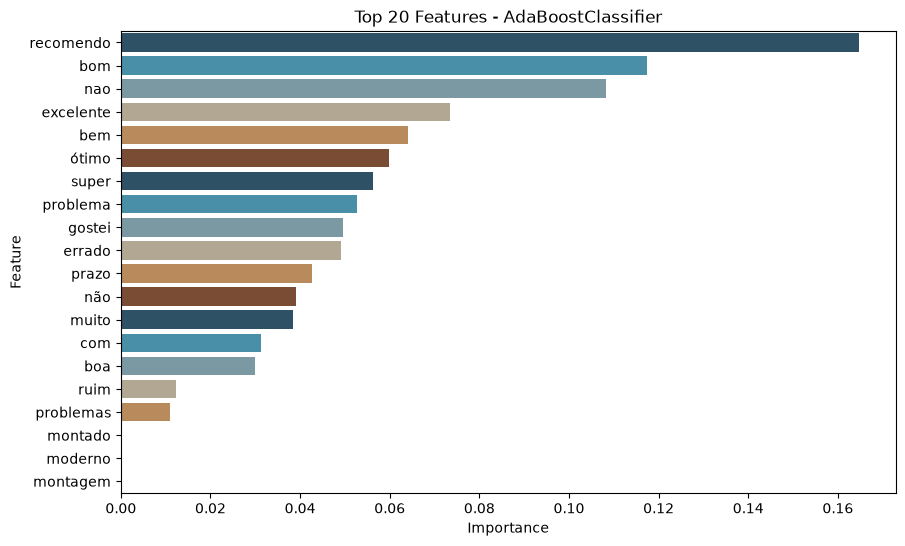

/tmp/ipykernel_10362/602648851.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=imp_df, palette=colors)
/tmp/ipykernel_10362/602648851.py:10: UserWarning: 
The palette list has fewer values (6) than needed (20) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x="Importance", y="Feature", data=imp_df, palette=colors)


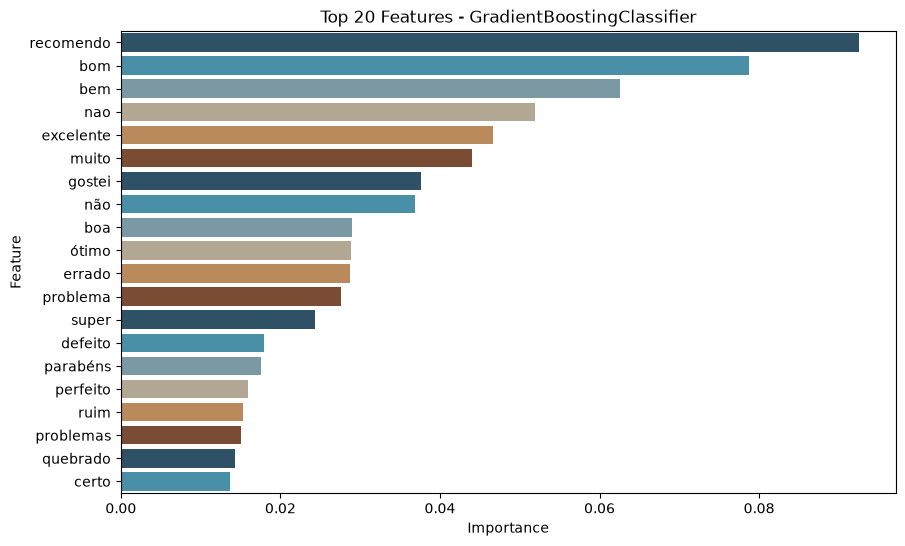

In [47]:
feature_importances = []
feature_names = vectorizer.get_feature_names_out()

for name, model in models.items():
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        imp_df = pd.DataFrame({"Feature": feature_names, "Importance": importances}).sort_values(by="Importance", ascending=False).head(20)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x="Importance", y="Feature", data=imp_df, palette=colors)
        plt.title(f"Top 20 Features - {name}")
        plt.show()

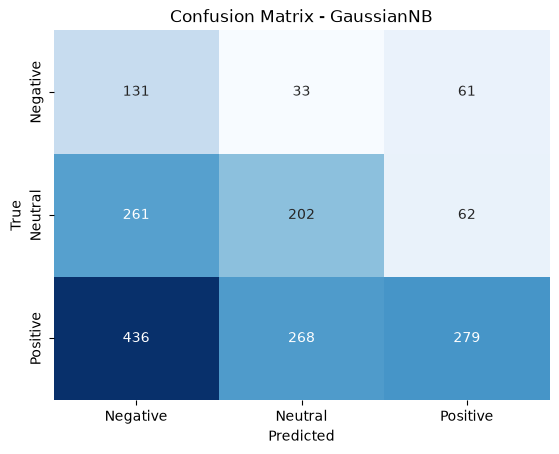

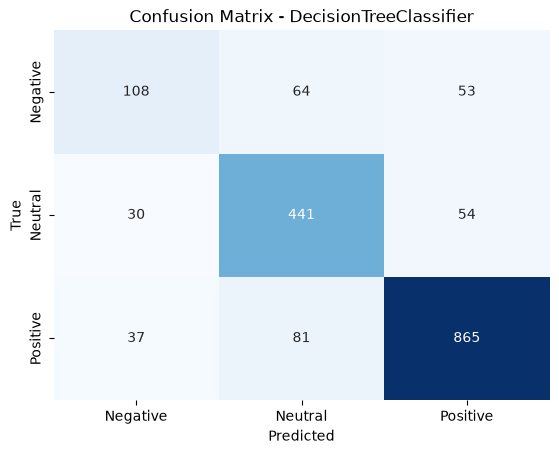

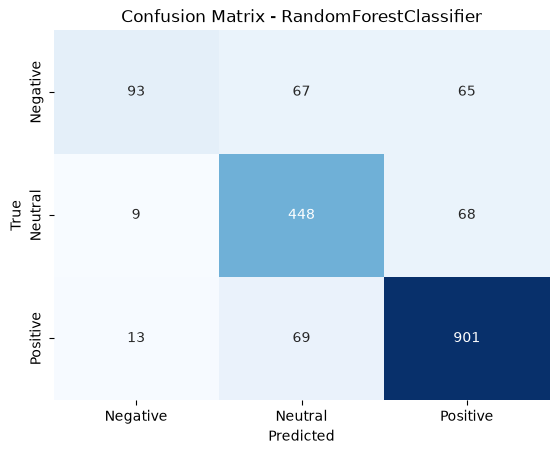

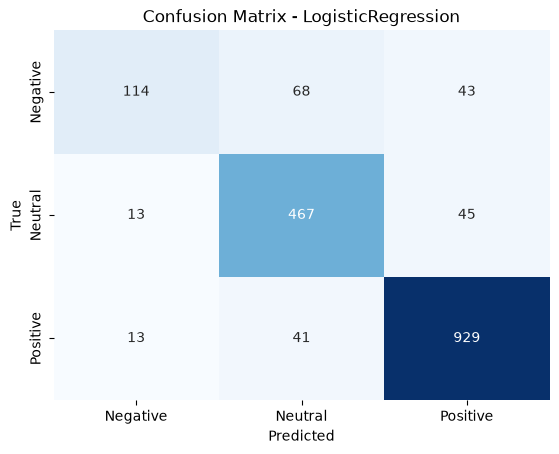

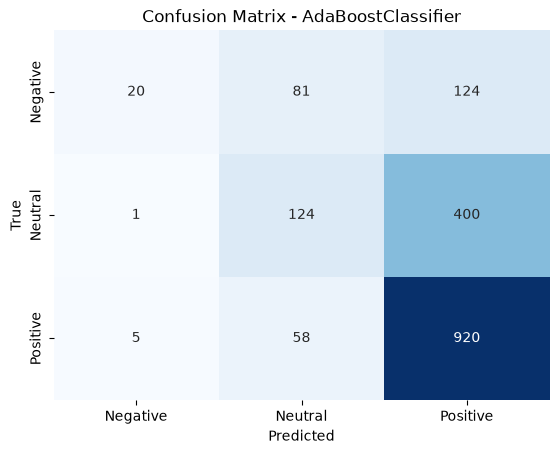

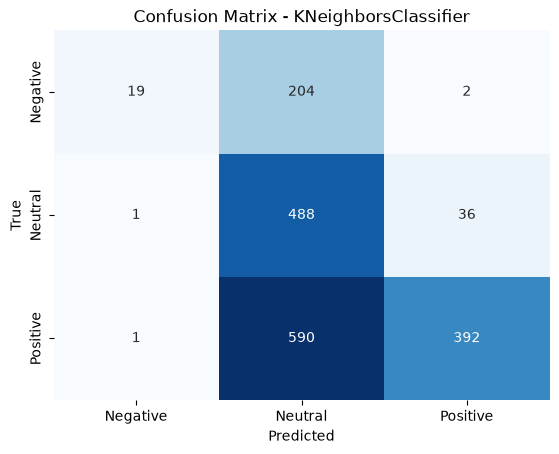

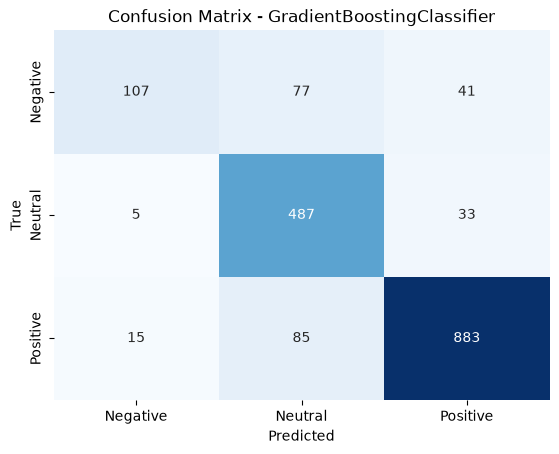

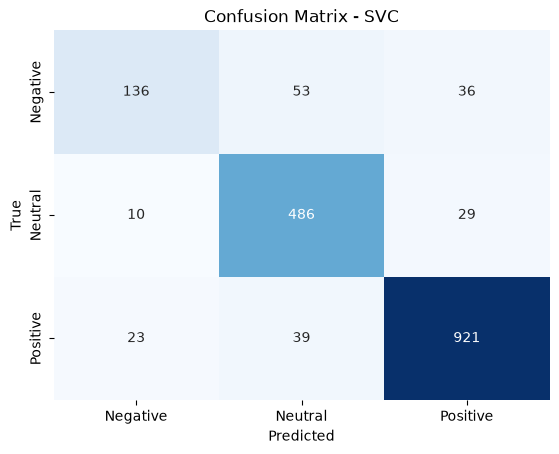

In [48]:
# Confusion matrix plots
for name, model in models.items():
    y_pred = model.predict(X_test_dense)
    cm = confusion_matrix(y_test_encoded, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, 
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

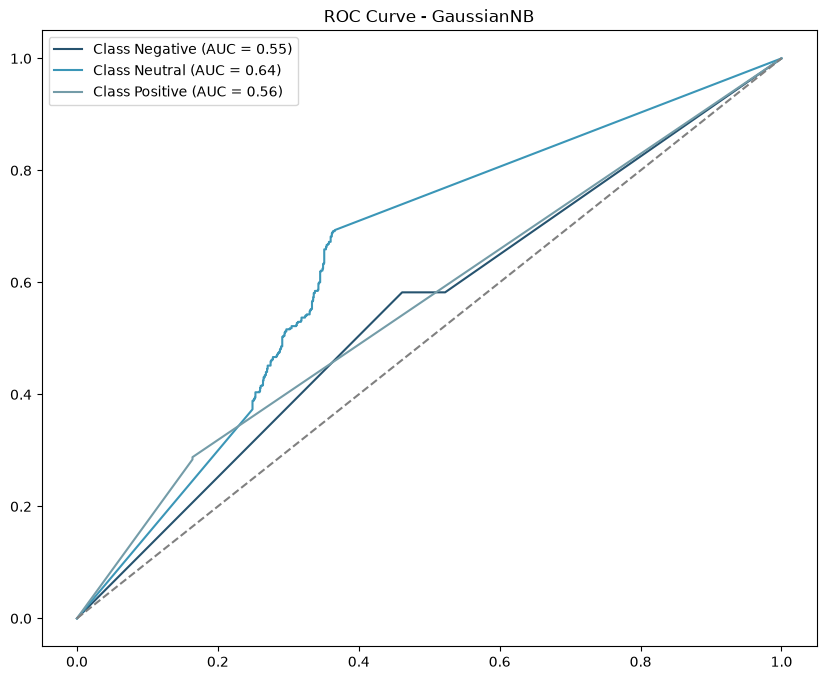

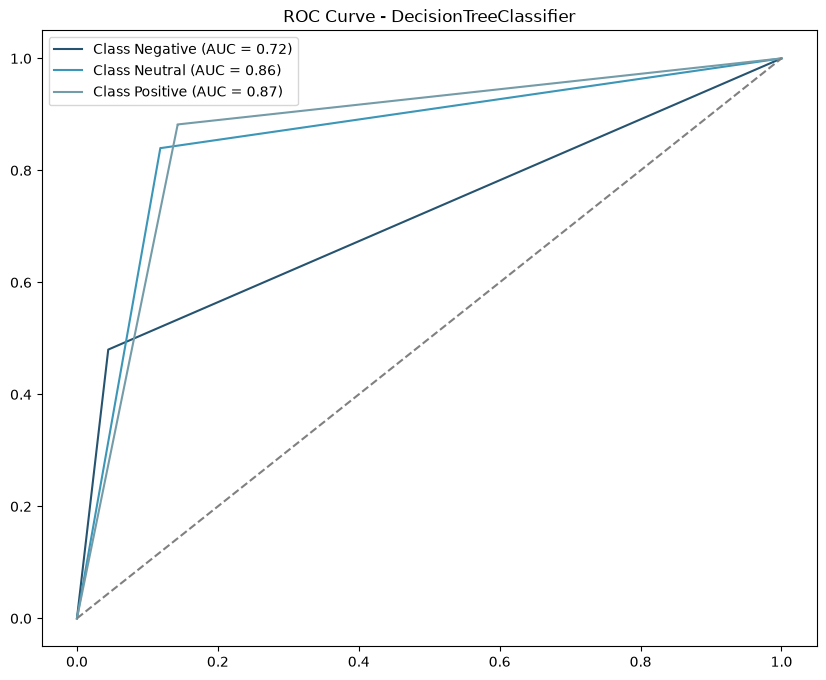

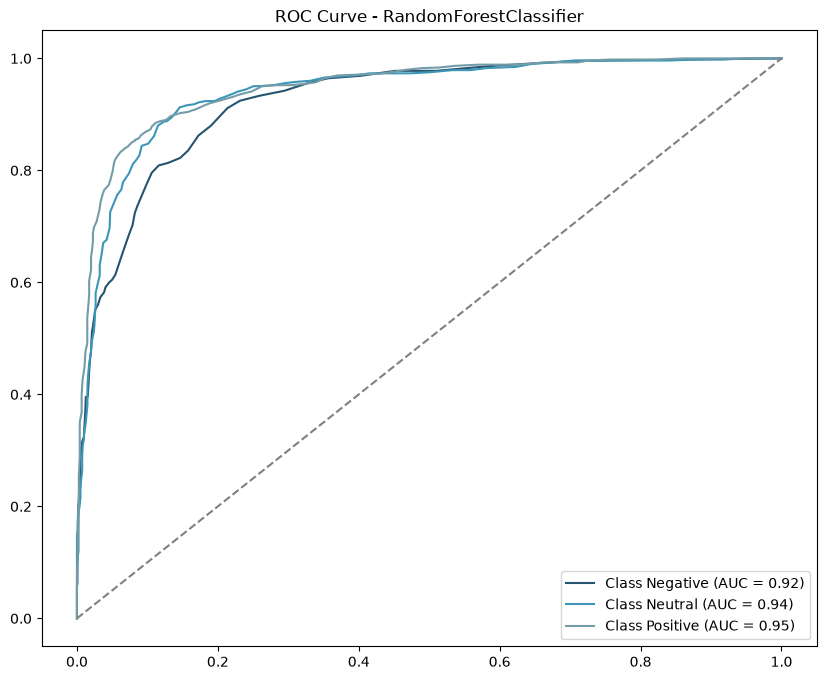

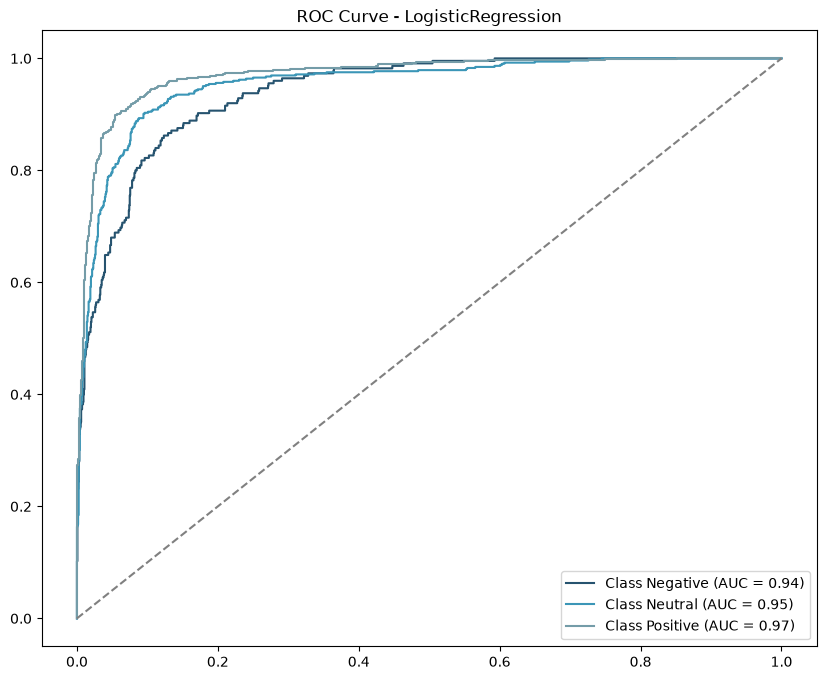

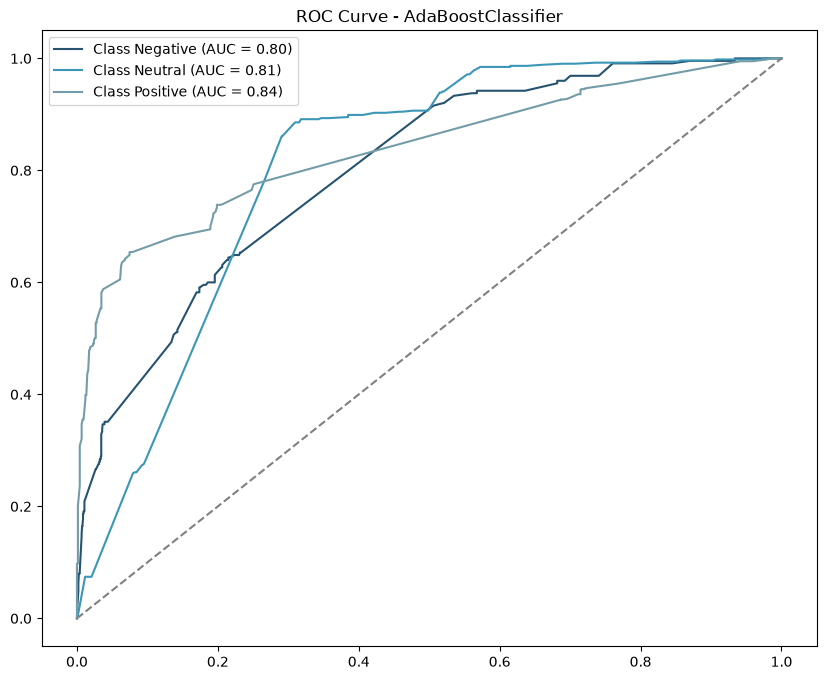

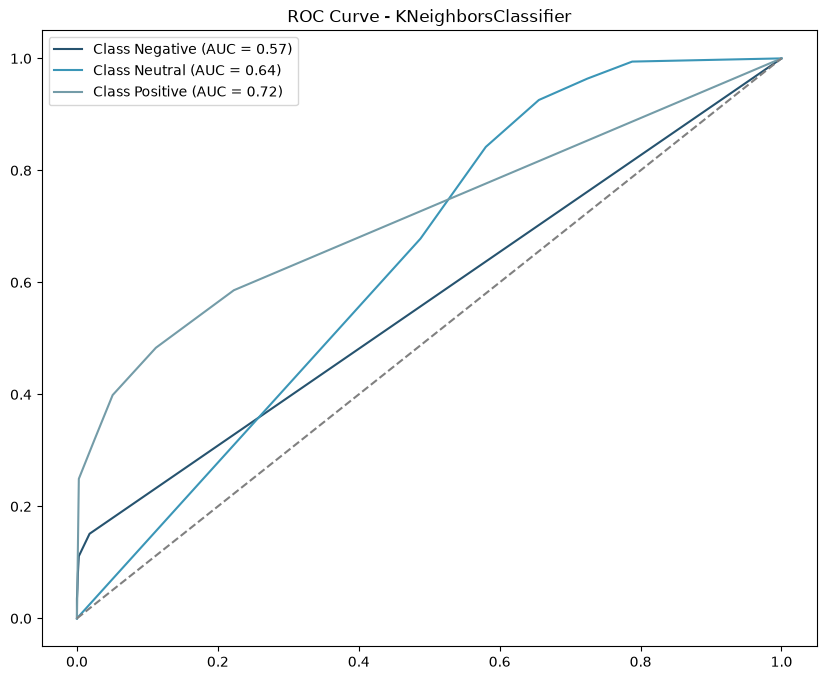

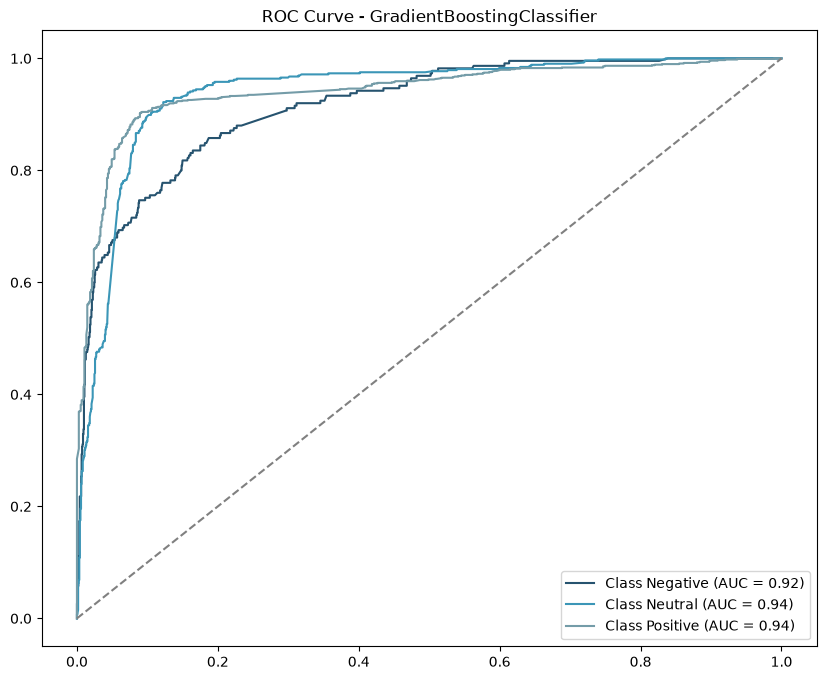

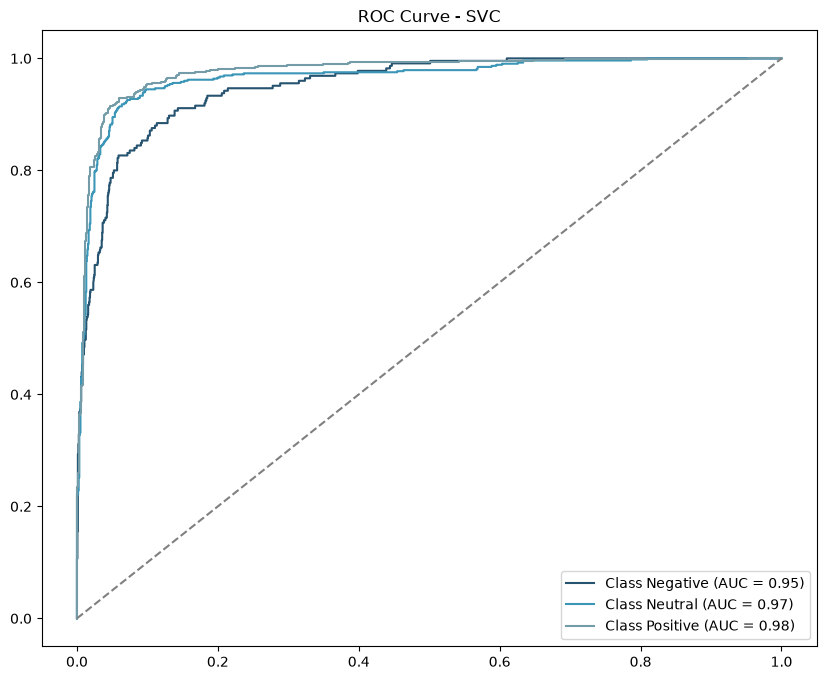

In [49]:
y_test_binarized = label_binarize(y_test_encoded, classes=np.unique(y_test_encoded))
n_classes = y_test_binarized.shape[1]

for name, model in models.items():
    plt.figure(figsize=(10, 8))
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_dense)
    else:
        y_decision = model.decision_function(X_test_dense)
        y_prob = (y_decision - y_decision.min()) / (y_decision.max() - y_decision.min())
    
    for class_id in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_binarized[:, class_id], y_prob[:, class_id])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {label_encoder.inverse_transform([class_id])[0]} (AUC = {roc_auc:.2f})")
    
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()

In [50]:
for name, model in models.items():
    y_pred = model.predict(X_test_dense)
    print(f"Classification Report for {name}")
    print(classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_))

Classification Report for GaussianNB
              precision    recall  f1-score   support

    Negative       0.16      0.58      0.25       225
     Neutral       0.40      0.38      0.39       525
    Positive       0.69      0.28      0.40       983

    accuracy                           0.35      1733
   macro avg       0.42      0.42      0.35      1733
weighted avg       0.54      0.35      0.38      1733

Classification Report for DecisionTreeClassifier
              precision    recall  f1-score   support

    Negative       0.62      0.48      0.54       225
     Neutral       0.75      0.84      0.79       525
    Positive       0.89      0.88      0.88       983

    accuracy                           0.82      1733
   macro avg       0.75      0.73      0.74      1733
weighted avg       0.81      0.82      0.81      1733

Classification Report for RandomForestClassifier
              precision    recall  f1-score   support

    Negative       0.81      0.41      0.55     

In [52]:
# Collect performance metrics
performance_data = []
for name, model in models.items():
    y_pred = model.predict(X_test_dense)
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test_encoded, y_pred),
        "Precision": precision_score(y_test_encoded, y_pred, average='weighted'),
        "Recall": recall_score(y_test_encoded, y_pred, average='weighted'),
        "F1-Score": f1_score(y_test_encoded, y_pred, average='weighted')
    }
    performance_data.append(metrics)

# Convert list of dictionaries to DataFrame
performance_df = pd.DataFrame(performance_data)

performance_df


,Model,Accuracy,Precision,Recall,F1-Score
0,GaussianNB,0.353145,0.535871,0.353145,0.379887
1,DecisionTreeClassifier,0.815926,0.812891,0.815926,0.812553
2,RandomForestClassifier,0.832083,0.831654,0.832083,0.822546
3,LogisticRegression,0.871321,0.869479,0.871321,0.865045
4,AdaBoostClassifier,0.613964,0.604093,0.613964,0.546067
5,KNeighborsClassifier,0.518754,0.749882,0.518754,0.498405
6,GradientBoostingClassifier,0.852279,0.860074,0.852279,0.846616
7,SVC,0.890364,0.889036,0.890364,0.887233
